[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/camel-2dcc/blob/mobile-js-test/notebooks/mobile_js_test.ipynb)

# Can a phone or tablet use this without signing in?

This notebook is a test, not a lesson. Every cell below was run before the notebook was saved, so
its **output is already stored in the file**. The question is which of those saved outputs still
work for someone who opens this page and never signs in to Google.

**How to run the test**

1. Open this page on the device you want to test. Do not sign in.
2. Scroll through every numbered test and follow its "Try this" line.
3. Write down PASS or FAIL for each number.
4. Then sign in, choose Runtime, then Run all, and do it again.

Nothing here changes any data, and nothing is saved anywhere.

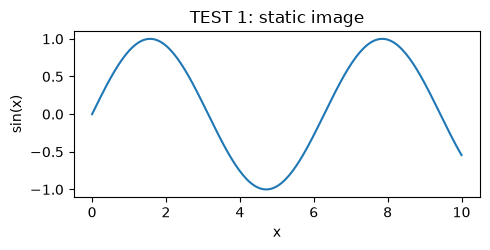

In [1]:
# TEST 1 of 10 - a plain picture (control)
# Try this: you should simply see a chart. If this fails, nothing else will work.
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

x = np.linspace(0, 10, 200)
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot(x, np.sin(x))
ax.set_title("TEST 1: static image")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
fig.tight_layout()
display(fig)
plt.close(fig)

In [2]:
# Build a small real dataset that the interactive tests below will carry inside themselves.
import json
import pathlib

import pandas as pd

SLICE = pathlib.Path("data/slice/camel-2dcc")
if not SLICE.exists():
    SLICE = pathlib.Path("../data/slice/camel-2dcc")

rows = []
if SLICE.exists():
    g = pd.read_csv(SLICE / "growth_summary.csv")
    g = g.dropna(subset=["growth_time_min", "rms_roughness_nm"])
    g = g[g["rms_roughness_nm"] < 10]
    for r in g.itertuples():
        rows.append({
            "id": int(r.sample_id),
            "material": str(r.material),
            "method": str(r.growth_method),
            "time": round(float(r.growth_time_min), 1),
            "rough": round(float(r.rms_roughness_nm), 3),
        })
    print(f"embedded {len(rows)} real 2DCC samples into the widgets below")
else:
    print("data slice not found; widgets below will be empty")

DATA_JSON = json.dumps(rows, separators=(",", ":"))
print(f"payload size: {len(DATA_JSON) / 1024:.0f} KB")

embedded 740 real 2DCC samples into the widgets below
payload size: 53 KB


In [3]:
# TEST 2 of 10 - Plotly, drawn the normal way
# Try this: touch a point to see its label. Pinch to zoom. Drag to pan.
import plotly.express as px

df = pd.DataFrame(rows)
fig2 = px.scatter(df, x="time", y="rough", color="material",
                  labels={"time": "growth time (min)", "rough": "roughness (nm)"},
                  title="TEST 2: Plotly, standard show()")
fig2.update_layout(height=380, margin=dict(l=10, r=10, t=40, b=10))
fig2.show()

In [4]:
# TEST 3 of 10 - the same Plotly chart, written out as self-contained HTML
# Try this: same as test 2. If test 2 fails and this one works, the difference is how it is embedded.
from IPython.display import HTML, display

html3 = fig2.to_html(include_plotlyjs="cdn", full_html=False, default_height="380px")
display(HTML("<h4>TEST 3: Plotly as embedded HTML</h4>" + html3))

In [5]:
# TEST 4 of 10 - hand-written HTML and JavaScript, no libraries at all
# Try this: tap the button several times. The count should go up.
display(HTML("""
<h4>TEST 4: plain HTML and JavaScript</h4>
<button id="t4b" style="font-size:18px;padding:12px 20px">Tap me</button>
<p style="font-size:18px">taps: <b id="t4n">0</b></p>
<script>
(function(){
  var n = 0;
  var b = document.getElementById('t4b'), o = document.getElementById('t4n');
  b.addEventListener('click', function(){ n += 1; o.textContent = n; });
})();
</script>
"""))

In [6]:
# TEST 5 of 10 - a slider that filters real data, all inside the page
# Try this: drag the slider. The count and the average should change as you drag.
display(HTML("""
<h4>TEST 5: slider filtering real samples</h4>
<label style="font-size:16px">show samples grown for at most
  <b><span id="t5v">60</span></b> minutes</label><br>
<input id="t5s" type="range" min="1" max="120" value="60" style="width:90%;height:36px">
<p style="font-size:18px">samples: <b id="t5n">-</b> &nbsp; average roughness:
  <b id="t5r">-</b> nm</p>
<script>
(function(){
  var data = __DATA__;
  var s = document.getElementById('t5s');
  function upd(){
    var lim = +s.value, k = 0, sum = 0;
    for (var i = 0; i < data.length; i++) {
      if (data[i].time <= lim) { k++; sum += data[i].rough; }
    }
    document.getElementById('t5v').textContent = lim;
    document.getElementById('t5n').textContent = k;
    document.getElementById('t5r').textContent = k ? (sum / k).toFixed(3) : '-';
  }
  s.addEventListener('input', upd);
  upd();
})();
</script>
""".replace("__DATA__", DATA_JSON)))

In [7]:
# TEST 6 of 10 - a chart drawn with a library loaded from the internet (D3)
# Try this: you should see blue bars. This tells us whether outside libraries load.
display(HTML("""
<h4>TEST 6: library loaded from a CDN (D3)</h4>
<div id="t6" style="font-size:16px">loading D3 from the internet...</div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.9.0/d3.min.js"></script>
<script>
(function(){
  var el = document.getElementById('t6');
  function draw(){
    if (typeof d3 === 'undefined') { el.textContent = 'D3 did not load (FAIL)'; return; }
    el.textContent = '';
    var vals = [4, 9, 6, 12, 3, 8];
    var svg = d3.select('#t6').append('svg').attr('width', 300).attr('height', 140);
    svg.selectAll('rect').data(vals).enter().append('rect')
      .attr('x', function(d, i){ return i * 48 + 6; })
      .attr('y', function(d){ return 130 - d * 9; })
      .attr('width', 40).attr('height', function(d){ return d * 9; })
      .attr('fill', '#2b6cb0');
  }
  setTimeout(draw, 1200);
})();
</script>
"""))

In [8]:
# TEST 7 of 10 - drawing with your finger on a canvas
# Try this: drag one finger inside the grey box. A line should follow your finger.
display(HTML("""
<h4>TEST 7: touch drawing on a canvas</h4>
<canvas id="t7" width="320" height="180"
        style="border:1px solid #888;background:#f4f4f4;touch-action:none"></canvas>
<script>
(function(){
  var c = document.getElementById('t7'), x = c.getContext('2d'), down = false;
  x.strokeStyle = '#c0392b'; x.lineWidth = 3;
  function pos(e){
    var r = c.getBoundingClientRect();
    var p = e.touches ? e.touches[0] : e;
    return [p.clientX - r.left, p.clientY - r.top];
  }
  function start(e){ down = true; var p = pos(e); x.beginPath(); x.moveTo(p[0], p[1]); e.preventDefault(); }
  function move(e){ if(!down) return; var p = pos(e); x.lineTo(p[0], p[1]); x.stroke(); e.preventDefault(); }
  function end(){ down = false; }
  c.addEventListener('mousedown', start); c.addEventListener('mousemove', move);
  c.addEventListener('mouseup', end); c.addEventListener('mouseleave', end);
  c.addEventListener('touchstart', start); c.addEventListener('touchmove', move);
  c.addEventListener('touchend', end);
})();
</script>
"""))

In [9]:
# TEST 8 of 10 - a page from another website, shown inside this notebook
# Try this: you should see the small "Example Domain" page. This is how a hosted widget would appear.
display(HTML("""
<h4>TEST 8: embedded external page</h4>
<iframe src="https://example.com" style="width:100%;height:200px;border:1px solid #888"></iframe>
"""))

In [10]:
# TEST 9 of 10 - an ipywidgets slider, which needs Python running behind it
# Try this: drag it. Without signing in it should be dead or missing. That is the expected result.
import ipywidgets as widgets

out9 = widgets.Output()
sl9 = widgets.IntSlider(value=5, min=0, max=20, description="value")


def _on9(change):
    with out9:
        out9.clear_output()
        print(f"Python saw: {change['new']}")


sl9.observe(_on9, names="value")
display(widgets.VBox([sl9, out9]))

### TEST 10 of 10 - a Colab form control

The cell below hides its code behind a form. **Try this:** does the dropdown appear at all, and
can you change it, without signing in? Changing it only matters when Python is running.

In [11]:
# @title TEST 10: Colab form control { display-mode: "form" }
material = "MoS2"  # @param ["MoS2", "WSe2", "WS2"]
max_minutes = 30  # @param {type:"slider", min:5, max:120, step:5}
sel = [r for r in rows if r["material"] == material and r["time"] <= max_minutes]
print(f"{len(sel)} samples of {material} grown for at most {max_minutes} minutes")
if sel:
    print(f"average roughness: {sum(r['rough'] for r in sel) / len(sel):.3f} nm")

316 samples of MoS2 grown for at most 30 minutes
average roughness: 0.926 nm


## What to report back

For each test, note PASS or FAIL twice: once signed out, once signed in and after Run all. Also
note the device and browser, for example "iPad, Safari" or "Android phone, Chrome", and whether
the page was slow to load.